## Modelos para la tercera entrega

Se seleccionaron las siguientes variables para climáticas para construir el modelo

| Variable | Significado                        | Justificación                   |
| -------- | ---------------------------------- | ------------------------------- |
| `bio01`  | Temperatura media anual            | General, robusta                |
| `bio03`  | Isotermalidad                      | Captura variabilidad térmica    |
| `bio04`  | Rango de temperatura anual         | Complementa `bio01`             |
| `bio07`  | Amplitud térmica anual             | Importante en zonas montañosas  |
| `bio12`  | Precipitación anual                | Indicador hídrico clave         |
| `bio15`  | Estacionalidad de la precipitación | Representa variabilidad hídrica |

In [1]:
import geopandas as gpd
import pandas as pd

wc = pd.read_csv('../data/WorldClim_v2.csv')



# Convertir a GeoDataFrame para reproyectar
geo = gpd.GeoDataFrame(
    wc,
    geometry=gpd.points_from_xy(wc['lon'], wc['lat']),
    crs='EPSG:4326'
)
#geo = geo.to_crs(epsg=3857)


## Matriz de pesos basada en distancias

In [2]:
import geopandas as gpd

# Leer un geopackage
cuencas = gpd.read_file('C:/Users/danie/Documents/ESPECIALIZACION-ANALITICA/03_Analisis Geoespacial/shapes/POMCAS.gpkg')

c:\Users\danie\miniconda3\envs\GeoSpatial\Lib\site-packages\pyogrio\raw.py:198: RuntimeWarning: Non-conformant content for record 1 in column Fecha_Ingr, 2021-05-06T00:00:00.0Z, successfully parsed
  return ogr_read(


In [3]:
cuencas.crs

<Projected CRS: PROJCS["MAGNA-SIRGAS / Origen-Nacional",GEOGCS["MA ...>
Name: MAGNA-SIRGAS / Origen-Nacional
Axis Info [cartesian]:
- [east]: Easting (metre)
- [north]: Northing (metre)
Area of Use:
- undefined
Coordinate Operation:
- name: unnamed
- method: Transverse Mercator
Datum: Marco Geocentrico Nacional de Referencia
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

In [3]:
# Reproyectar las ocurrencias al crs de las cuencas
geo = geo.to_crs(cuencas.crs)
geo.crs

<Projected CRS: PROJCS["MAGNA-SIRGAS / Origen-Nacional",GEOGCS["MA ...>
Name: MAGNA-SIRGAS / Origen-Nacional
Axis Info [cartesian]:
- [east]: Easting (metre)
- [north]: Northing (metre)
Area of Use:
- undefined
Coordinate Operation:
- name: unnamed
- method: Transverse Mercator
Datum: Marco Geocentrico Nacional de Referencia
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

<Axes: >

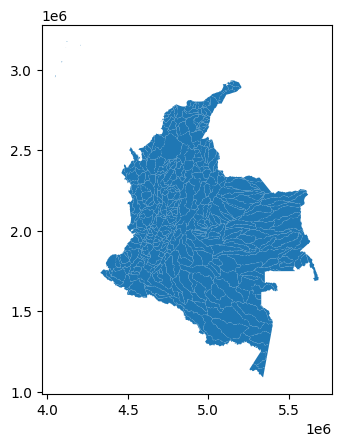

In [140]:
cuencas.plot()

In [4]:
# Seleccionar solo los polígonos que contienen al menos un punto
# la forma más eficiente con unary_union
cuencas_ocur = cuencas[cuencas.geometry.intersects(geo.unary_union)]

C:\Users\danie\AppData\Local\Temp\ipykernel_14340\4213889930.py:3: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  cuencas_ocur = cuencas[cuencas.geometry.intersects(geo.unary_union)]


<Axes: >

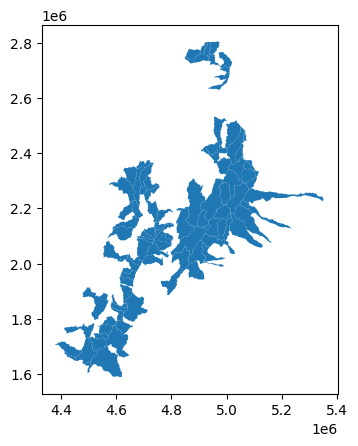

In [142]:
cuencas_ocur.plot()

In [58]:
colombia = cuencas.dissolve()
#colombia.to_file('C:/Users/danie/Documents/ESPECIALIZACION-ANALITICA/03_Analisis Geoespacial/shapes/colombia.gpkg', driver='GPKG')

Para evaluar la dependencia espacial mejor le damos la resolución del tamaño de cada pixel, como si tuvieramos una grilla. Para eso sacamos la grilla para todo colombia a partir de una de la imagenes geotiff.

In [59]:
import geopandas as gpd
import rasterio
import rasterio.mask
from rasterio.features import shapes
from shapely.geometry import shape

# Leer el shapefile de Colombia (puede ser .gpkg o .shp)
colombia = colombia.to_crs('EPSG:4326')  # porque WorldClim está en EPSG:4326

# Leer raster
raster_path = 'C:/Users/danie/Documents/ESPECIALIZACION-ANALITICA/03_Analisis Geoespacial/WorldClim_Bio_Images\\wc2.1_30s_bio_1.tif'

with rasterio.open(raster_path) as src:
    # Recortar a Colombia
    out_image, out_transform = rasterio.mask.mask(src, colombia.geometry, crop=True)
    out_meta = src.meta.copy()

# Extraer geometría de celdas del raster recortado
mask = out_image[0] != src.nodata

results = (
    {'properties': {'value': v}, 'geometry': s}
    for i, (s, v) in enumerate(
        shapes(out_image[0], mask=mask, transform=out_transform)
    )
)

# Construir GeoDataFrame
geoms = []
for r in results:
    geom = shape(r['geometry'])
    geoms.append(geom)

grid = gpd.GeoDataFrame({'geometry': geoms}, crs='EPSG:4326')
grid['cell_id'] = grid.index

print(f'Grid creada: {len(grid)} celdas.')


Grid creada: 1140416 celdas.


In [5]:
grid = grid.to_crs(epsg=9377) # Poner todo en el mismo sistema de coordeadas
grid.crs

NameError: name 'grid' is not defined

In [6]:
geo = geo.to_crs(epsg=4326) 
geo.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [7]:
pomca = cuencas_ocur.copy() # solo donde hay ocurrencias
#pomca = cuencas.copy() # todas las cuencas

In [8]:
geo.columns
#grid.columns

Index(['Unnamed: 0', 'countryCode', 'elevation_DEM', 'genus', 'lat', 'lon',
       'species', 'bio1', 'bio3', 'bio4', 'bio7', 'bio12', 'bio15', '.geo',
       'geometry'],
      dtype='object')

### Extraer el valor medio de los puntos dentro de las celdas
No es una buena práctica realmente

In [67]:
# Spatial join: asignar cada punto a su celda
join = gpd.sjoin(geo, grid, how='inner', predicate='within')

# Ver resultado: cada punto con su 'cell_id'
print(join[['species', 'cell_id', 'elevation_DEM','bio1', 'bio3', 'bio4', 'bio7', 'bio12', 'bio15']].head())

# Contar número de especies únicas por celda
conteo = join.groupby('cell_id')['species'].nunique()
# Número total de puntos por celda (sin importar especie)
conteo_puntos = join.groupby('cell_id').size()

bio1_mean = join.groupby('cell_id')['bio1'].mean()
bio3_mean = join.groupby('cell_id')['bio3'].mean()
bio4_mean = join.groupby('cell_id')['bio4'].mean()
bio7_mean = join.groupby('cell_id')['bio7'].mean()
bio12_mean = join.groupby('cell_id')['bio12'].mean()
bio15_mean = join.groupby('cell_id')['bio15'].mean()
elevation_mean = join.groupby('cell_id')['elevation_DEM'].mean()

# Agregar esa columna a la grilla
grid['num_species'] = grid['cell_id'].map(conteo).fillna(0).astype(int)
grid['num_points'] = grid['cell_id'].map(conteo_puntos).fillna(0).astype(int)
grid['bio1_mean'] = grid['cell_id'].map(bio1_mean)
grid['bio3_mean'] = grid['cell_id'].map(bio3_mean)
grid['bio4_mean'] = grid['cell_id'].map(bio4_mean)
grid['bio7_mean'] = grid['cell_id'].map(bio7_mean)
grid['bio12_mean'] = grid['cell_id'].map(bio12_mean)
grid['bio15_mean'] = grid['cell_id'].map(bio15_mean)
grid['elevation_mean'] = grid['cell_id'].map(elevation_mean)

# Ver las celdas con conteo
print(grid[['cell_id', 'num_species','num_points']].head())

                 species  cell_id  elevation_DEM      bio1       bio3  \
0    Espeletia corymbosa   452097           2940  1.175000  79.234962   
1     Espeletia argentea   452097           2940  1.175000  79.234962   
2  Espeletia grandiflora   452097           2940  1.175000  79.234962   
3    Espeletia corymbosa   484107           3509  0.832083  80.940598   
4  Espeletia grandiflora   484107           3509  0.832083  80.940598   

       bio4  bio7   bio12      bio15  
0  2.938769  1.22  1119.0  33.725811  
1  2.938769  1.22  1119.0  33.725811  
2  2.938769  1.22  1119.0  33.725811  
3  3.222493  1.01  1169.0  39.870544  
4  3.222493  1.01  1169.0  39.870544  
   cell_id  num_species  num_points
0        0            0           0
1        1            0           0
2        2            0           0
3        3            0           0
4        4            0           0


In [71]:
grid = grid[grid['num_species'] > 0].copy()  # Filtrar celdas con al menos una especie
grid.shape

(1779, 11)

In [ ]:
# Spatial join: asignar cada punto a su celda
# pomca = pomca[['Id', 'AH', 'NOMAH', 'ZH', 'NOMZH', 'SZH', 'NOMSZH', 'Area_Ha', 'geometry']]
# join_pomca = gpd.sjoin(grid, pomca, how='inner', predicate='within')


NameError: name 'pomca' is not defined

In [ ]:
# # Spatial join: asignar cada punto a su celda
# join = gpd.sjoin(geo, pomca[['Id', 'AH', 'NOMAH', 'ZH', 'NOMZH', 'SZH', 'NOMSZH', 'Area_Ha']], how='inner', predicate='within')

# # Ver resultado: cada punto con su 'cell_id'
# # print(join[['species', 'Id','elevation_DEM','bio1', 'bio3', 'bio4', 'bio7', 'bio12', 'bio15']].head())

# # Contar número de especies únicas por celda
# conteo = join.groupby('Id')['species'].nunique()
# # Número total de puntos por celda (sin importar especie)
# conteo_puntos = join.groupby('Id').size()
# bio1_mean = join.groupby('Id')['bio1'].mean()
# bio3_mean = join.groupby('Id')['bio3'].mean()
# bio4_mean = join.groupby('Id')['bio4'].mean()
# bio7_mean = join.groupby('Id')['bio7'].mean()
# bio12_mean = join.groupby('Id')['bio12'].mean()
# bio15_mean = join.groupby('Id')['bio15'].mean()

# # Agregar esa columna a la grilla
# pomca['num_species'] = pomca['Id'].map(conteo).fillna(0).astype(int)
# pomca['num_points'] = pomca['Id'].map(conteo_puntos).fillna(0).astype(int)
# pomca['bio1_mean'] = pomca['Id'].map(bio1_mean).fillna(0)
# pomca['bio3_mean'] = pomca['Id'].map(bio3_mean).fillna(0)
# pomca['bio4_mean'] = pomca['Id'].map(bio4_mean).fillna(0)
# pomca['bio7_mean'] = pomca['Id'].map(bio7_mean).fillna(0)
# pomca['bio12_mean'] = pomca['Id'].map(bio12_mean).fillna(0)
# pomca['bio15_mean'] = pomca['Id'].map(bio15_mean).fillna(0)

# # Ver las celdas con conteo
# print(pomca[['Id', 'num_species','num_points']].head())

                 species         Id  elevation_DEM      bio1       bio3  \
0    Espeletia corymbosa  POMCA_076           2940  1.175000  79.234962   
1     Espeletia argentea  POMCA_076           2940  1.175000  79.234962   
2  Espeletia grandiflora  POMCA_076           2940  1.175000  79.234962   
3    Espeletia corymbosa  POMCA_076           3509  0.832083  80.940598   
4  Espeletia grandiflora  POMCA_076           3509  0.832083  80.940598   

       bio4  bio7   bio12      bio15  
0  2.938769  1.22  1119.0  33.725811  
1  2.938769  1.22  1119.0  33.725811  
2  2.938769  1.22  1119.0  33.725811  
3  3.222493  1.01  1169.0  39.870544  
4  3.222493  1.01  1169.0  39.870544  
          Id  num_species  num_points
0  POMCA_135            1           1
2  POMCA_137            1          10
3  POMCA_140            1           1
4  POMCA_170            1           4
5  POMCA_142            1          24


C:\Users\danie\AppData\Local\Temp\ipykernel_31200\3988004063.py:2: UserWarning: CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS: EPSG:9377
Right CRS: PROJCS["MAGNA-SIRGAS / Origen-Nacional",GEOGCS["MA ...

  join = gpd.sjoin(geo, pomca, how='inner', predicate='within')


### Usar raster satatistic para extraer el valor del raster para todo el poligono

In [12]:
import glob
import os

images = []
for n in ['1','3','4','7','12','15']:
    file = f'C:/Users/danie/Documents/ESPECIALIZACION-ANALITICA/03_Analisis Geoespacial/WorldClim_Bio_Images/wc2.1_30s_bio_{n}.tif'
    images.append(file)
# for file in glob.glob("C:/Users/danie/Documents/ESPECIALIZACION-ANALITICA/03_Analisis Geoespacial/WorldClim_Bio_Images/*.tif"):
#     # images.append(os.path.basename(file)) # Solo el archivo
#     images.append(file) 

In [13]:
images

['C:/Users/danie/Documents/ESPECIALIZACION-ANALITICA/03_Analisis Geoespacial/WorldClim_Bio_Images/wc2.1_30s_bio_1.tif',
 'C:/Users/danie/Documents/ESPECIALIZACION-ANALITICA/03_Analisis Geoespacial/WorldClim_Bio_Images/wc2.1_30s_bio_3.tif',
 'C:/Users/danie/Documents/ESPECIALIZACION-ANALITICA/03_Analisis Geoespacial/WorldClim_Bio_Images/wc2.1_30s_bio_4.tif',
 'C:/Users/danie/Documents/ESPECIALIZACION-ANALITICA/03_Analisis Geoespacial/WorldClim_Bio_Images/wc2.1_30s_bio_7.tif',
 'C:/Users/danie/Documents/ESPECIALIZACION-ANALITICA/03_Analisis Geoespacial/WorldClim_Bio_Images/wc2.1_30s_bio_12.tif',
 'C:/Users/danie/Documents/ESPECIALIZACION-ANALITICA/03_Analisis Geoespacial/WorldClim_Bio_Images/wc2.1_30s_bio_15.tif']

In [8]:
pomca.columns

Index(['Id', 'AH', 'NOMAH', 'ZH', 'NOMZH', 'SZH', 'NOMSZH', 'Cod_POMCA',
       'Nom_POMCA', 'Jurisd_Dpt', 'Car_Lider', 'Car_CC', 'Fuente_Fin', 'Fase',
       'Nom_Fase', 'Res_Adop', 'Año_Res', 'Area_Ha', 'Observacio',
       'Fecha_Ingr', 'Fecha_Reco', 'Shape_Leng', 'geometry'],
      dtype='object')

In [9]:
pomca = pomca.to_crs(epsg=4326) # Poner todo en el mismo sistema de coordeadas
print(pomca.crs)
geo.crs

EPSG:4326


<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [10]:
from rasterstats import zonal_stats

# --- Spatial join para species (esto sí se hace con los puntos) ---
join = gpd.sjoin(
    geo,
    pomca[['Id', 'AH', 'NOMAH', 'ZH', 'NOMZH', 'SZH', 'NOMSZH', 'Area_Ha', 'geometry']],
    how='inner',
    predicate='within'
)

# --- Conteo de species por POMCA ---
# Número de especies únicas por POMCA
conteo = join.groupby('Id')['species'].nunique()

# Número total de puntos por POMCA
conteo_puntos = join.groupby('Id').size()

# Asignar conteos a POMCA
pomca['num_species'] = pomca['Id'].map(conteo).fillna(0).astype(int)
pomca['num_points'] = pomca['Id'].map(conteo_puntos).fillna(0).astype(int)

# --- Zonal stats para biovariables ---
# IMPORTANTE: Asocia cada variable a su raster
bio_vars = {
    'bio1': 'C:/Users/danie/Documents/ESPECIALIZACION-ANALITICA/03_Analisis Geoespacial/WorldClim_Bio_Images/wc2.1_30s_bio_1.tif',
    'bio3': 'C:/Users/danie/Documents/ESPECIALIZACION-ANALITICA/03_Analisis Geoespacial/WorldClim_Bio_Images/wc2.1_30s_bio_3.tif',
    'bio4': 'C:/Users/danie/Documents/ESPECIALIZACION-ANALITICA/03_Analisis Geoespacial/WorldClim_Bio_Images/wc2.1_30s_bio_4.tif',
    'bio7': 'C:/Users/danie/Documents/ESPECIALIZACION-ANALITICA/03_Analisis Geoespacial/WorldClim_Bio_Images/wc2.1_30s_bio_7.tif',
    'bio12': 'C:/Users/danie/Documents/ESPECIALIZACION-ANALITICA/03_Analisis Geoespacial/WorldClim_Bio_Images/wc2.1_30s_bio_12.tif',
    'bio15': 'C:/Users/danie/Documents/ESPECIALIZACION-ANALITICA/03_Analisis Geoespacial/WorldClim_Bio_Images/wc2.1_30s_bio_15.tif'
}

# Loop por cada raster → 1 sola vez
for var, tif_path in bio_vars.items():
    zs = zonal_stats(pomca, tif_path, stats=['mean'])
    pomca[f'{var}_mean'] = [x['mean'] for x in zs]

# --- Elevation ---
zs_elev = zonal_stats(
    pomca,
    'C:/Users/danie/Documents/ESPECIALIZACION-ANALITICA/03_Analisis Geoespacial/WorldClim_Bio_Images/wc2.1_30s_elev.tif',
    stats=['mean']
)
pomca['elevacion'] = [x['mean'] for x in zs_elev]

# --- Verificación ---
print(pomca[['Id', 'num_species', 'num_points',
             'bio1_mean', 'bio3_mean', 'bio4_mean',
             'bio7_mean', 'bio12_mean', 'bio15_mean',
             'elevacion']].head())



          Id  num_species  num_points  bio1_mean  bio3_mean  bio4_mean  \
0  POMCA_135            1           1  15.481010  88.146698  22.219454   
2  POMCA_137            1          10  16.618288  89.895073  22.901094   
3  POMCA_140            1           1  19.474751  90.410153  25.080060   
4  POMCA_170            1           4  19.353293  91.634219  26.183173   
5  POMCA_142            1          24  17.282496  91.396436  23.583131   

   bio7_mean   bio12_mean  bio15_mean    elevacion  
0  12.132751  1980.715731   35.492223  2234.253910  
2  11.136698  1621.974638   37.177488  2080.901656  
3  11.187329  1522.286537   36.989893  1634.950324  
4  10.571384  1502.913846   36.889856  1617.976923  
5  10.682237  1490.094482   37.727894  1984.999244  


In [11]:
pomca.columns

Index(['Id', 'AH', 'NOMAH', 'ZH', 'NOMZH', 'SZH', 'NOMSZH', 'Cod_POMCA',
       'Nom_POMCA', 'Jurisd_Dpt', 'Car_Lider', 'Car_CC', 'Fuente_Fin', 'Fase',
       'Nom_Fase', 'Res_Adop', 'Año_Res', 'Area_Ha', 'Observacio',
       'Fecha_Ingr', 'Fecha_Reco', 'Shape_Leng', 'geometry', 'num_species',
       'num_points', 'bio1_mean', 'bio3_mean', 'bio4_mean', 'bio7_mean',
       'bio12_mean', 'bio15_mean', 'elevacion'],
      dtype='object')

In [12]:
# Filtrar: solo celdas con al menos 1 punto (puedes usar num_points o num_species)
# pomca_filt = pomca[pomca['num_points'] > 0].copy()
pomca_filt = pomca[['Id', 'AH', 'NOMAH', 'ZH', 'NOMZH', 'SZH', 'NOMSZH', 'Area_Ha','num_species', 'num_points',
             'bio1_mean', 'bio3_mean', 'bio4_mean', 'bio7_mean', 'bio12_mean', 'bio15_mean','elevacion', 'geometry']].copy() # todas las cuencas
pomca_filt.shape


(95, 18)

In [ ]:
# convertir a factor
# pomca_filt['cell_id'] = grid_filt['cell_id'].astype('category')

In [ ]:
# Filtrar polígonos con área > 0
#pomca_filt = pomca_filt[pomca_filt['Area_Ha'] > 0].copy()
# pomca_filt = join_pomca[join_pomca['num_species'] > 0].copy()
# pomca_filt.shape

(1390, 20)

In [13]:
pomca_filt.columns

Index(['Id', 'AH', 'NOMAH', 'ZH', 'NOMZH', 'SZH', 'NOMSZH', 'Area_Ha',
       'num_species', 'num_points', 'bio1_mean', 'bio3_mean', 'bio4_mean',
       'bio7_mean', 'bio12_mean', 'bio15_mean', 'elevacion', 'geometry'],
      dtype='object')

### Indice de Moran

In [ ]:
import numpy as np

# Crear columna de densidad de especies por km2
# pomca_filt['sp_density'] = pomca_filt['num_species'] / (pomca_filt['Area_Ha'] / 100)  # convertir de Ha a Km2
# #pomca_filt['log_sp_density'] = np.log1p(pomca_filt['sp_density'])
# pomca_filt['sp_density'].isna().sum()  # Ver si hay NaN

np.int64(0)

In [14]:
pomca_filt['sp_density'] = pomca_filt['num_species'] / pomca_filt.geometry.area

C:\Users\danie\AppData\Local\Temp\ipykernel_14340\720122719.py:1: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  pomca_filt['sp_density'] = pomca_filt['num_species'] / pomca_filt.geometry.area


In [15]:
from libpysal.weights import DistanceBand


# Crear matriz DistanceBand (por ejemplo 20 km)
w_dist20km = DistanceBand.from_dataframe(pomca_filt, threshold=20000, binary=False)
w_dist50km = DistanceBand.from_dataframe(pomca_filt, threshold=50000, binary=False)
w_dist100km = DistanceBand.from_dataframe(pomca_filt, threshold=100000, binary=False)

c:\Users\danie\miniconda3\envs\GeoSpatial\Lib\site-packages\scipy\sparse\_data.py:128: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)


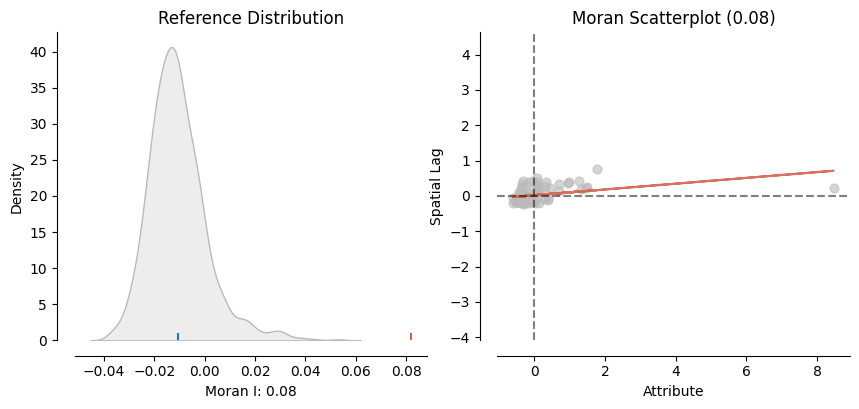

In [17]:
import esda
from splot.esda import plot_moran

# Moran para distancia de 30 km
mi = esda.Moran(pomca_filt['sp_density'], w_dist20km)
plot_moran(mi);

In [17]:
mi.I, mi.p_sim, mi.z_sim

(np.float64(0.19685578102626364),
 np.float64(0.001),
 np.float64(11.838937372428905))

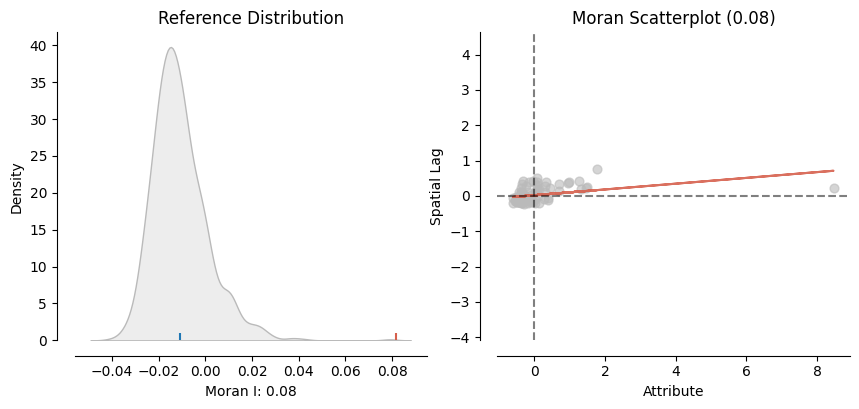

In [ ]:
# Moran con 50 km
plot_moran(esda.Moran(pomca_filt['sp_density'], w_dist50km));

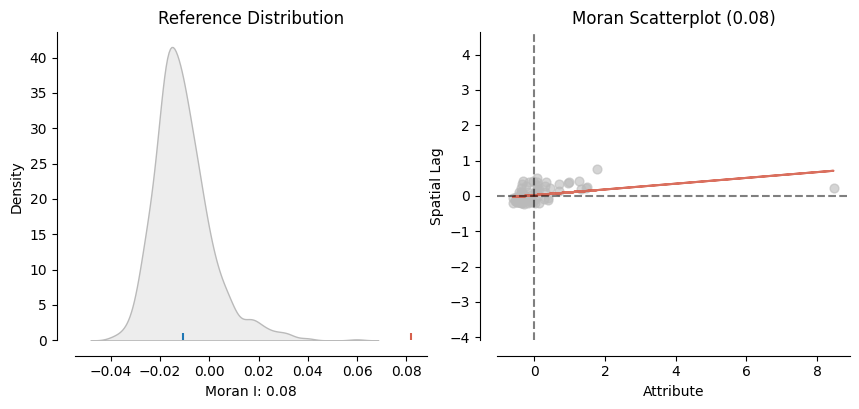

In [19]:
# Moran con 200 km
plot_moran(esda.Moran(pomca_filt['sp_density'], w_dist100km));

In [22]:
from pysal.lib import weights

# Primero para numero de especies
pomca_filt['num_species_std'] = (pomca_filt['num_species'] - pomca_filt['num_species'].mean()) / pomca_filt['num_species'].std()
pomca_filt['w_num_species_std'] = weights.lag_spatial(w_dist50km, pomca_filt['num_species_std'])

# Ahora para numero de ocurrencias
pomca_filt['num_points_std'] = (pomca_filt['num_points'] - pomca_filt['num_points'].mean()) / pomca_filt['num_points'].std()
pomca_filt['w_num_points_std'] = weights.lag_spatial(w_dist50km, pomca_filt['num_points_std'])

# Ahora para densidad de especies
pomca_filt['sp_density_std'] = (pomca_filt['sp_density'] - pomca_filt['sp_density'].mean()) / pomca_filt['sp_density'].std()
pomca_filt['w_sp_density_std'] = weights.lag_spatial(w_dist50km, pomca_filt['sp_density_std'])

In [22]:
pomca_filt.columns

Index(['Id', 'AH', 'NOMAH', 'ZH', 'NOMZH', 'SZH', 'NOMSZH', 'Area_Ha',
       'num_species', 'num_points', 'bio1_mean', 'bio3_mean', 'bio4_mean',
       'bio7_mean', 'bio12_mean', 'bio15_mean', 'elevacion', 'geometry',
       'sp_density', 'num_species_std', 'w_num_species_std', 'num_points_std',
       'w_num_points_std', 'sp_density_std', 'w_sp_density_std'],
      dtype='object')

In [ ]:
#pomca_filt.to_file('../data/regresion_POMCA.geojson', driver="GeoJSON")

### A partir de acá podemos traer el dataframe listo

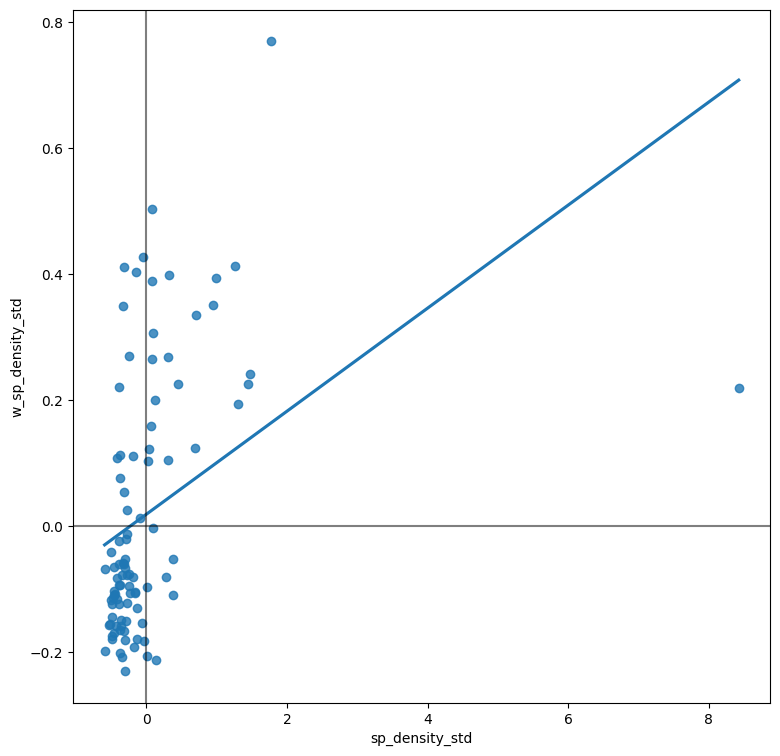

In [25]:
# Grafico LISA
import seaborn as sbn
import matplotlib.pyplot as plt

# Setup the figure and axis
f, ax = plt.subplots(1, figsize=(9, 9))
# Plot values
sbn.regplot(x='sp_density_std', y='w_sp_density_std', data=pomca_filt, ci=None)
# Add vertical and horizontal lines
plt.axvline(0, c='k', alpha=0.5)
plt.axhline(0, c='k', alpha=0.5)
# plt.text(1.75, 0.5, "HH", fontsize=25)
# plt.text(1.5, -1.5, "HL", fontsize=25)
# plt.text(-2, 1, "LH", fontsize=25)
# plt.text(-1.5, -2.5, "LL", fontsize=25)
# Display
plt.show()

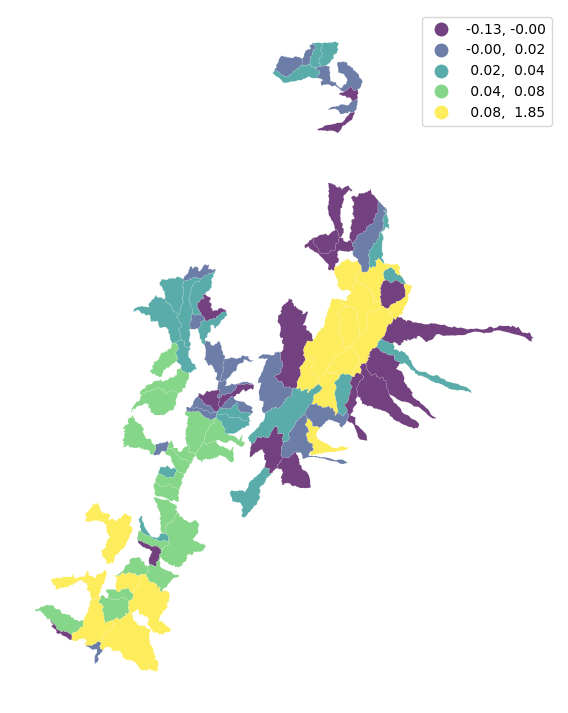

In [27]:
lisa = esda.Moran_Local(pomca_filt['sp_density'], w_dist50km)
f, ax = plt.subplots(1, figsize=(9,9))
pomca_filt['Is'] = lisa.Is
pomca_filt.plot(column='Is', cmap='viridis', scheme='quantiles',k=5, edgecolor='white', linewidth=0.1, alpha=0.75, legend=True,ax=ax);
ax.set_axis_off()

In [28]:
# Break observations into significant or not
pomca_filt['significant'] = lisa.p_sim < 0.05
# Store the quadrant they belong to
pomca_filt['quadrant'] = lisa.q

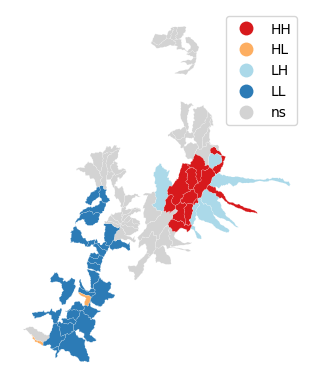

In [29]:
from splot.esda import lisa_cluster
lisa_cluster(lisa, pomca_filt);

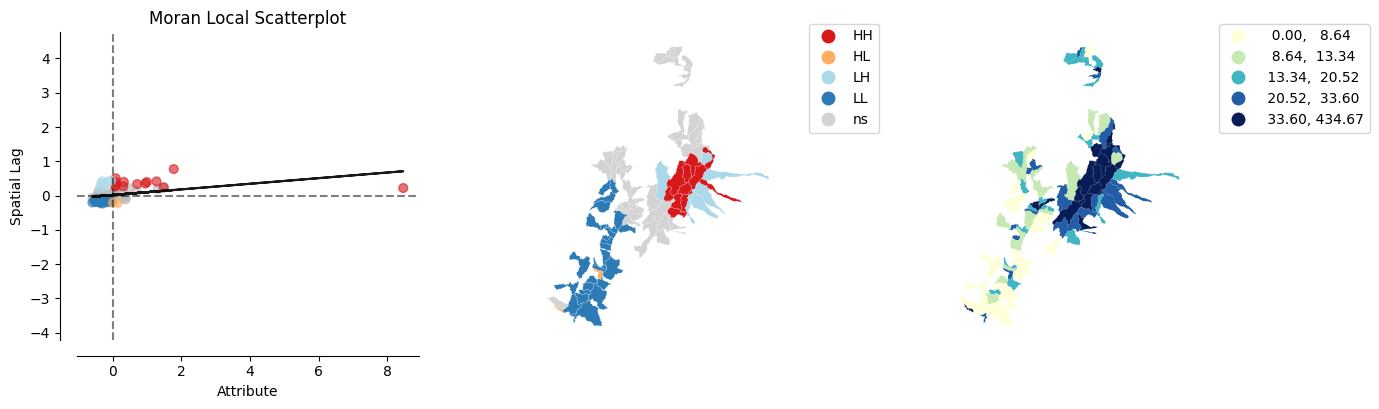

In [30]:
from splot.esda import plot_local_autocorrelation
plot_local_autocorrelation(lisa, pomca_filt, 'sp_density');

In [31]:
# Probando K-means
from esda.moran import Moran
import numpy as np
import libpysal.weights.set_operations as Wsets
from libpysal.weights import Queen, KNN
import seaborn as sns
from pysal.lib import weights
import geopandas as gpd
import contextily as cx
from sklearn import cluster
from sklearn.cluster import KMeans, AgglomerativeClustering

In [32]:
kmeans5 = cluster.KMeans(n_clusters=5)
k5cls = kmeans5.fit(pomca_filt[['sp_density']]);

c:\Users\danie\miniconda3\envs\GeoSpatial\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [33]:
k5cls.labels_

array([4, 0, 0, 4, 0, 3, 0, 4, 3, 0, 0, 4, 2, 3, 0, 2, 2, 4, 3, 0, 0, 0,
       0, 0, 4, 4, 4, 3, 3, 4, 0, 2, 2, 0, 0, 4, 0, 3, 4, 4, 4, 4, 3, 4,
       4, 4, 3, 3, 3, 0, 0, 3, 3, 0, 0, 0, 4, 0, 0, 0, 0, 0, 4, 0, 0, 0,
       3, 0, 4, 3, 0, 1, 4, 4, 4, 4, 3, 4, 4, 3, 0, 3, 2, 2, 4, 4, 0, 3,
       0, 4, 4, 3, 4, 0, 3], dtype=int32)

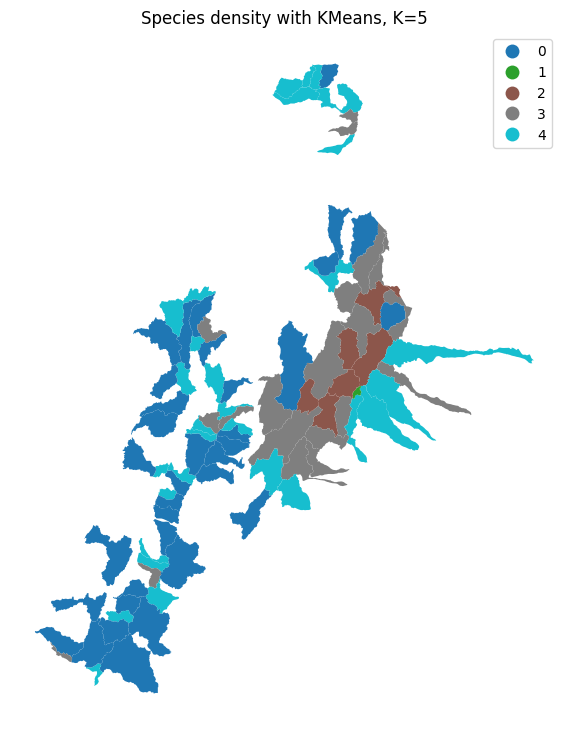

In [34]:
import matplotlib.pyplot as plt

pomca_filt['k5cls'] = k5cls.labels_

# Setup figure and ax
f, ax = plt.subplots(1, figsize=(9, 9))
# Plot unique values choropleth including a legend and with no boundary lines
pomca_filt.plot(column='k5cls', categorical=True, legend=True, linewidth=0, ax=ax)
# Remove axis
ax.set_axis_off()
# Add title
plt.title('Species density with KMeans, K=5')
# Display the map
plt.show()

In [ ]:
# pomca_filt.to_csv('../data/pomca_filt.csv', index=False)